# Mapping the Narrative Journey: A Structural Analysis of Podcast Conversations

**Notebook:** Initial analysis, testing, and implementation of semantic segmentation and topic modeling pipelines.

**Dataset:** SPoRC (Podcast Corpus)

**Goal:** Develop and evaluate methods to segment podcast transcripts into coherent narrative units.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
nltk.download("punkt")

# For topic modeling, graph modeling, visualization
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import plotly.graph_objects as go

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Load and Explore Data

#### Load the full SPoRC dataset

In [ ]:
# Load the SPoRC dataset (12G!)
#dataset = load_dataset("blitt/SPoRC")

episodeLevelData.jsonl.gz:   0%|          | 0.00/12.3G [00:00<?, ?B/s]

#### Load sample subset of the SPoRC dataset

In [8]:
# Path to your sample file
file_path_episode = r"C:\Users\Sadik\Desktop\NLP Project\episodeLevelDataSample.jsonl"
file_path_spkr = r"C:\Users\Sadik\Desktop\NLP Project\speakerTurnDataSample.jsonl"
dataset_sample = pd.read_json(file_path_episode, lines=True) # Reads JSONL line by line
spkr_data = pd.read_json(file_path_spkr, lines=True)

In [12]:
# print(f"Number of episodes: {len(dataset_sample)}")
# print(f"Columns: \n{list(dataset_sample.columns)}")
dataset_sample.head(2)
#dataset_sample.info()
# spkr_data.head()

,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
0,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,Best of SingOut SpeakOut No.3,<p>Best of with snippets from 3 episodes and a...,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,[SPEAKER_00],1.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,60.0,0.0,1.0
1,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,It's All Gone,<p>Simon introduces &apos;It&apos;s all Gone&a...,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,"[SPEAKER_00, SPEAKER_01, SPEAKER_02]",3.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,120.053333,0.0,3.0


In [ ]:
spkr_data.iloc[7]['turnText'] wgqwjdhqg
#spkr_data.head() scdw cdemdwegr32

" to Sing Out Speak Out episode number 20. I know crazy, it's going fast this crazy year that we are having 2020. I know for a lot of people the hard lockdown and the restrictions due to COVID-19 are still in full force and in Australia we are very lucky that we've managed to squash that curve for now due I think in part because we have a smaller population and we had advanced warning of what was happening in other countries so I think that held us in good stead but we're not over it yet of course and we're not gloating in any way whatsoever. But I know it can be tough when you're stuck in the same situation even if you might still have a job but you're working from home and one day you're homeschooling the next day you're doing your job at home and next day it's the weekend but it doesn't really feel like the weekend because you can't go anywhere. Every day is a bit the same. It's like Groundhog Day basically. So as I'm introducing songs to the Kiss Tone album Way to Nowhere which I m

#### Preview first transcript

In [95]:
episode = dataset_sample.iloc[5]["transcript"] # the first episodes transcript
# print(f"Transcript sample: {episode[:500]}...") # preview the first 500 chars
len(episode)

# description = dataset_sample.iloc[0]['epDescription']
# description

30450

### Semantic Segmentation Functions

In [40]:
#model = SentenceTransformer("all-MiniLM-L6-v2")
model = SentenceTransformer("all-mpnet-base-v2")

In [ ]:
def segment_fixed_threshold(text, model, threshold=0.7, percentile_threshold=25):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    threshold = np.percentile(sim, percentile_threshold)    #a different approach
    breaks = [i + 1 for i, sc in enumerate(sim) if sc < threshold]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, sim


def segment_adaptive(text, model, window=3, prominence=0.05, drop_factor=0.85):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], [], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    peaks, _ = find_peaks(inverted, prominence=prominence)
    breaks = [p for p in peaks if smooth[p] < drop_factor * np.mean(smooth)]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, smooth, peaks


def segment_coherence(segments, model):
    vals = []
    for seg in segments:
        sents = sent_tokenize(seg)
        if len(sents) < 2: 
            continue
        embs = model.encode(sents)
        sims = [cosine_similarity([embs[i]], [embs[j]])[0][0]
                for i in range(len(embs)) for j in range(i + 1,len(embs))]
        vals.append(np.mean(sims))
    return np.mean(vals) if vals else 0

def plot_similarity_curve(sim_scores, peaks=None, title="Similarity Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(sim_scores, label="Semantic Similarity")

    if peaks is not None and len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    
    plt.title(title)
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()

### Testing the hyper parameter for the adaptive version

In [96]:
sample_text = episode
win = [[2, 2, 2, 2, 2, 2], [3, 3, 3, 3, 3, 3], [4, 4, 4, 4, 4, 4], [5, 5, 5, 5, 5, 5], [6, 6, 6, 6, 6, 6]]
prom = [0.06, 0.07, 0.08, 0.09, 0.1]
for j in range(len(win)):
    for i, (window, prominence) in enumerate(zip(win[j], prom), start=1):
        segments, _, _ = segment_adaptive(sample_text, model, window, prominence)
        print(f"{5*'-'} Test {j} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.243

----- Test 1 -----
Adaptive coherence: 0.234

----- Test 1 -----
Adaptive coherence: 0.226

----- Test 1 -----
Adaptive coherence: 0.222

----- Test 1 -----
Adaptive coherence: 0.216

----- Test 1 -----
Adaptive coherence: 0.214

----- Test 2 -----
Adaptive coherence: 0.202

----- Test 2 -----
Adaptive coherence: 0.200

----- Test 2 -----
Adaptive coherence: 0.202

----- Test 2 -----
Adaptive coherence: 0.201

----- Test 2 -----
Adaptive coherence: 0.200

----- Test 3 -----
Adaptive coherence: 0.204

----- Test 3 -----
Adaptive coherence: 0.204

----- Test 3 -----
Adaptive coherence: 0.201

----- Test 3 -----
Adaptive coherence: 0.201

----- Test 3 -----
Adaptive coherence: 0.198

----- Test 4 -----
Adaptive coherence: 0.197

----- Test 4 -----
Adaptive cohere

### Testing the hyper parameter for the fixed version

In [62]:
sample_text = episode
percentile_threshold = [5, 10, 15, 20, 25, 30, 40, 45, 50, 55, 60, 70, 80, 90]
for i, percentile in enumerate(percentile_threshold, start=1):
    segments, _ = segment_fixed_threshold(sample_text, model,threshold, percentile)
    print(f"{5*'-'} Test {i} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

----- Test 1 -----
Adaptive coherence: 0.204

----- Test 2 -----
Adaptive coherence: 0.240

----- Test 3 -----
Adaptive coherence: 0.252

----- Test 4 -----
Adaptive coherence: 0.259

----- Test 5 -----
Adaptive coherence: 0.271

----- Test 6 -----
Adaptive coherence: 0.282

----- Test 7 -----
Adaptive coherence: 0.320

----- Test 8 -----
Adaptive coherence: 0.342

----- Test 9 -----
Adaptive coherence: 0.361

----- Test 10 -----
Adaptive coherence: 0.384

----- Test 11 -----
Adaptive coherence: 0.413

----- Test 12 -----
Adaptive coherence: 0.471

----- Test 13 -----
Adaptive coherence: 0.537

----- Test 14 -----
Adaptive coherence: 0.648



### Test Semantic Segmentation on One Episode

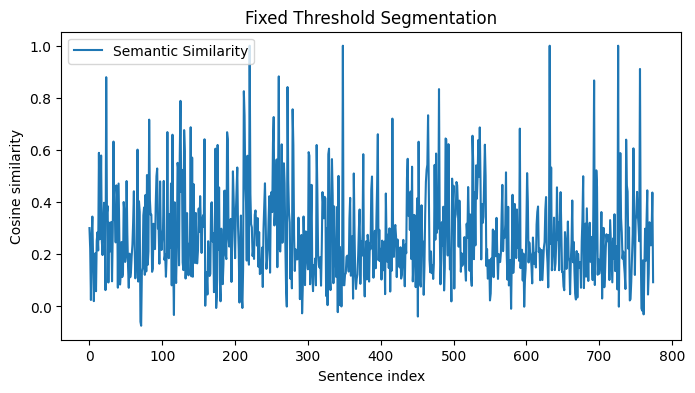

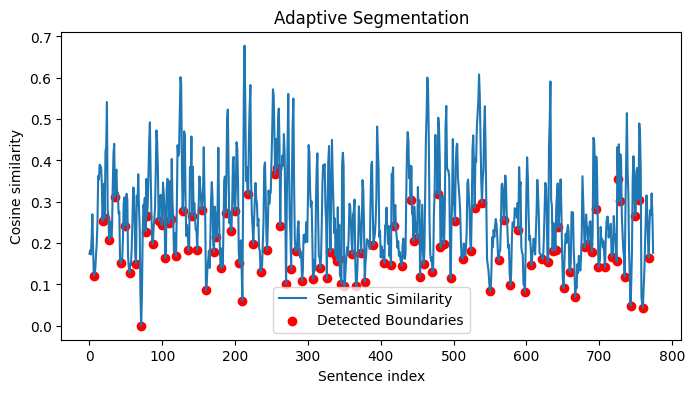

Fixed: 195 segments 
Adaptive: 77 segments
Fixed coherence: 0.271
Adaptive coherence: 0.200


In [ ]:
sample_text = episode

segments_fixed, sim_fixed = segment_fixed_threshold(sample_text, model)
segments_adapt, sim_adapt, peaks = segment_adaptive(sample_text, model)

plot_similarity_curve(sim_fixed, title="Fixed Threshold Segmentation")
plot_similarity_curve(sim_adapt, peaks, title="Adaptive Segmentation")

print(f"Fixed: {len(segments_fixed)} segments \nAdaptive: {len(segments_adapt)} segments")
print(f"Fixed coherence: {segment_coherence(segments_fixed, model):.3f}")
print(f"Adaptive coherence: {segment_coherence(segments_adapt, model):.3f}")


In [46]:

print("\n" + "="*30)
print("PODCAST ADAPT_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_adapt):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")

print("\n" + "="*30)
print("PODCAST FIXED_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_fixed):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")


PODCAST ADAPT_SEGMENTATION RESULTS

--- SEGMENT 1 ---

 [Music] Welcome to "Brazing Education" with Educator Barnes. A podcast was a focus on speaking your truth, being transparent to others, and having no shame about it. Because we can't move forward until the truth is known. [Music] [Music] Hello everyone, Educator Barnes here, and today I have a special guest, Natalie Pippkin, and she is from Black World Schoolers. And I've been following her on Instagram, one of the things I've been very interested in is school choice. And a lot of times when people think about school choice, they think about charter schools versus traditional public schools.

--------------------

--- SEGMENT 2 ---

But there's more than that. You have homeschoolers, you have unschooling, you have online school, you have people that do a blend of both. And I wanted to get this perspective, especially with the pandemic happening right now, and people are at home. And not that that's the same as homeschooling, I'm 

### Evaluate on Multiple Episodes

,episode_id,epTitle,podTitle,num_sentences,fixed_segments,adaptive_segments,fixed_coherence,adaptive_coherence,overlapPropDuration,numMainSpeakers,avgTurnDuration
0,0,Best of SingOut SpeakOut No.3,SingOut SpeakOut,8,8,1,0,0.169082,0.000000,1.0,60.000000
1,1,It's All Gone,SingOut SpeakOut,5,5,1,0,0.115270,0.000000,3.0,120.053333
2,2,Today Is Yesterday,SingOut SpeakOut,20,20,3,0,0.226153,0.001847,4.0,30.400000
3,3,Saturn Return,SingOut SpeakOut,28,28,4,0,0.234314,0.005649,3.0,39.683333
4,4,Quarterlife Crisis,SingOut SpeakOut,19,19,3,0,0.247114,0.035983,3.0,33.978667


<Axes: title={'center': 'Overlap vs. Coherence'}, xlabel='overlapPropDuration', ylabel='adaptive_coherence'>

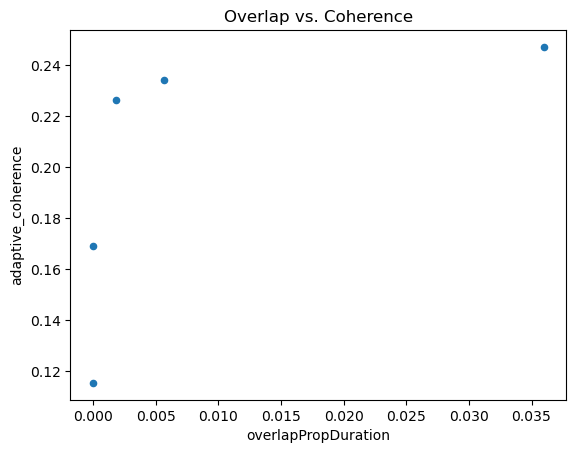

In [8]:
results = []
for i, row in dataset_sample.head(5).iterrows():
    text = row["transcript"]
    if not isinstance(text, str) or len(text.split()) < 50:
        continue

    seg_fixed, sim_fixed = segment_fixed_threshold(text, model)
    seg_adapt, sim_adapt, peaks = segment_adaptive(text, model)
    results.append({
        "episode_id": i,
        "epTitle": row["epTitle"],
        "podTitle": row["podTitle"],
        "num_sentences": len(sent_tokenize(text)),
        "fixed_segments": len(seg_fixed),
        "adaptive_segments": len(seg_adapt),
        "fixed_coherence": segment_coherence(seg_fixed, model),
        "adaptive_coherence": segment_coherence(seg_adapt, model),
        "overlapPropDuration": row.get("overlapPropDuration", np.nan),
        "numMainSpeakers": row.get("numMainSpeakers", np.nan),
        "avgTurnDuration": row.get("avgTurnDuration", np.nan)
    })
    
results_df = pd.DataFrame(results)
display(results_df)

results_df.plot.scatter(x="overlapPropDuration", y="adaptive_coherence", title="Overlap vs. Coherence")

### Prototype Topic Modeling and Graph Analysis

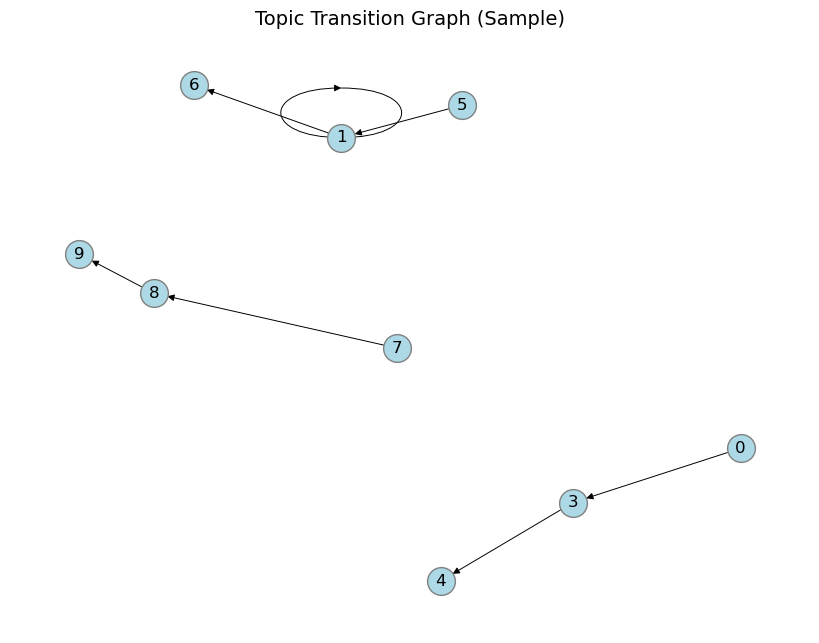

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words="english")
kmeans = KMeans(n_clusters=10, random_state=42) #maybe HDBSCAN
topic_model = BERTopic(hdbscan_model=kmeans, vectorizer_model=vectorizer)

segments_dataset = pd.DataFrame({
    "episode_id": results_df["episode_id"].repeat(results_df["adaptive_segments"]).reset_index(drop=True),
    "text": [seg for ep in dataset_sample.head(5)["transcript"].apply(lambda x: segment_adaptive(x, model)[0]) for seg in ep]
})
topics, probs = topic_model.fit_transform(segments_dataset["text"])
segments_dataset["topic"] = topics

# Build topic graph
edges = []
for eid, group in segments_dataset.groupby("episode_id"):
    seq = list(group["topic"])
    for a,b in zip(seq[:-1], seq[1:]): edges.append((a,b))
G = nx.DiGraph()
for e in edges:
    if G.has_edge(e[0], e[1]):
        G[e[0]][e[1]]["weight"] += 1
    else:
        G.add_edge(e[0], e[1], weight=1)
    
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
weights = [max(0.7, min(G[u][v]["weight"]/2, 3)) for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=400, width=weights, edgecolors="gray")
plt.title("Topic Transition Graph (Sample)", fontsize=14)
plt.show()

### Adaptive segmentation on 5 episodes

##### Load 5 episodes

In [10]:
# Selecting first 5 episodes
num_episodes = 5
dataset_sample_subset = dataset_sample.head(num_episodes)

##### Adaptive Segmentation & Similarity Curves

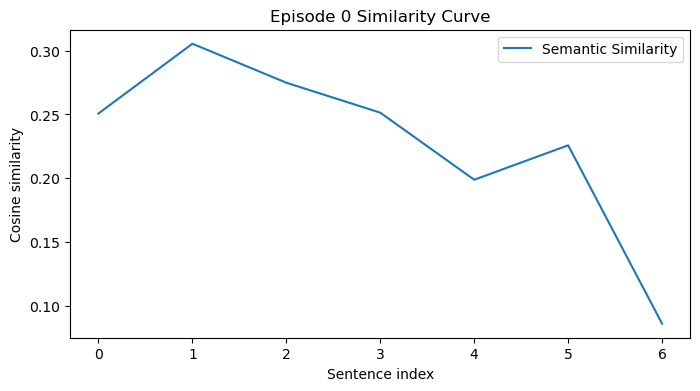

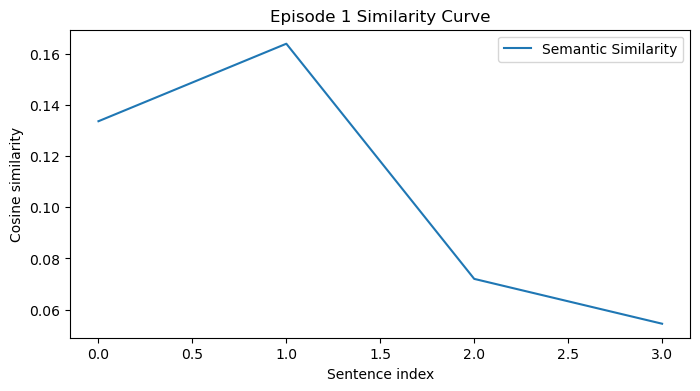

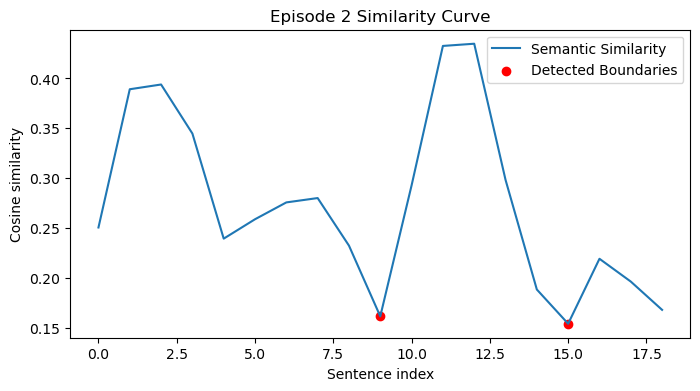

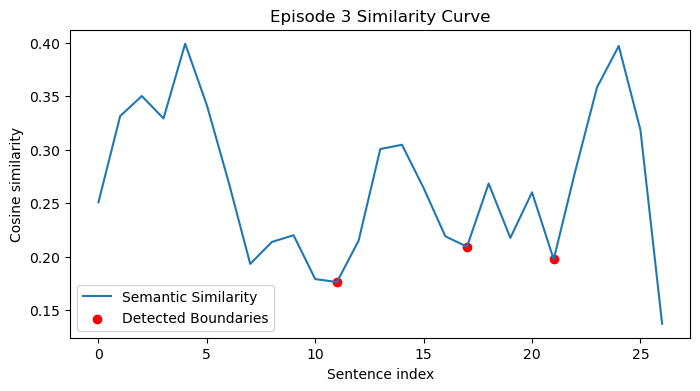

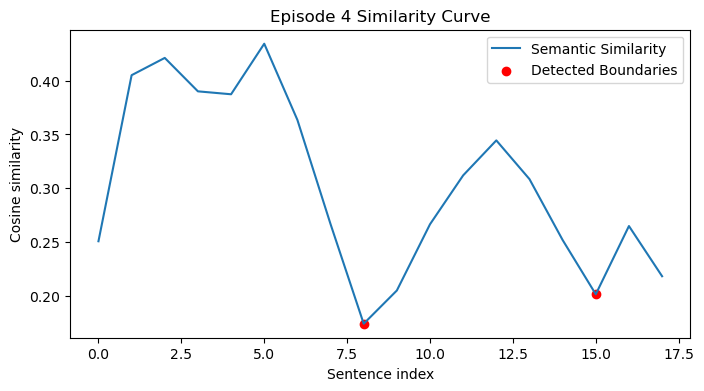

Total segments extracted: 12


,episode_id,epTitle,podTitle,segment_text
0,0,Best of SingOut SpeakOut No.3,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
1,1,It's All Gone,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
2,2,Today Is Yesterday,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
3,2,Today Is Yesterday,SingOut SpeakOut,So as I'm introducing songs to the Kiss Tone a...
4,2,Today Is Yesterday,SingOut SpeakOut,Without further adieu this is track four from ...


In [11]:
# Sentence transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Adaptive segmentation and similarity curves
segments_list = []

for i, row in dataset_sample_subset.iterrows():
    transcript = row["transcript"]
    if not isinstance(transcript, str) or len(transcript.split()) < 50:
        continue
    
    # Apply adaptive segmentation
    segments, sim_scores, peaks = segment_adaptive(transcript, model)
    
    # Plot similarity curve for each episode
    plt.figure(figsize=(8,4))
    plt.plot(sim_scores, label="Semantic Similarity")
    if len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    plt.title(f"Episode {i} Similarity Curve")
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()
    
    # Save segments in list
    for seg in segments:
        segments_list.append({
            "episode_id": i,
            "epTitle": row.get("epTitle", f"Episode {i}"),
            "podTitle": row.get("podTitle", "Unknown Podcast"),
            "segment_text": seg
        })

# Convert to DataFrame
segments_df = pd.DataFrame(segments_list)
print(f"Total segments extracted: {len(segments_df)}")
segments_df.head()

##### Topic Modeling with BERTopic

In [12]:
vectorizer = CountVectorizer(ngram_range=(1,2), stop_words="english")
kmeans = KMeans(n_clusters=10, random_state=42)
topic_model = BERTopic(hdbscan_model=kmeans, vectorizer_model=vectorizer)

# Fit topic model
topics, probs = topic_model.fit_transform(segments_df["segment_text"])
segments_df["topic"] = topics

# Preview topics
topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,2,0_ive_day_sing speak_speak,"[ive, day, sing speak, speak, sing, youre, afr...",[ I'm Simon Shapiro and this is Sing Out Speak...
1,1,2,1_music_music music_dont way_way,"[music, music music, dont way, way, dont, toda...",[So as I'm introducing songs to the Kiss Tone ...
2,2,1,2_believe_fantasy_believe believe_ive,"[believe, fantasy, believe believe, ive, just,...",[ I'm Simon Shapiro and this is Sing Out Speak...
3,3,1,3_ive_im_week_keystone,"[ive, im, week, keystone, album, ive afraid, a...",[ I'm Simon Shapiro and this is Sing Out Speak...
4,4,1,4_maybe_track_actually_people,"[maybe, track, actually, people, winehouse, wa...",[Write a comment maybe you could do some tips ...


##### Topic Transition Graph

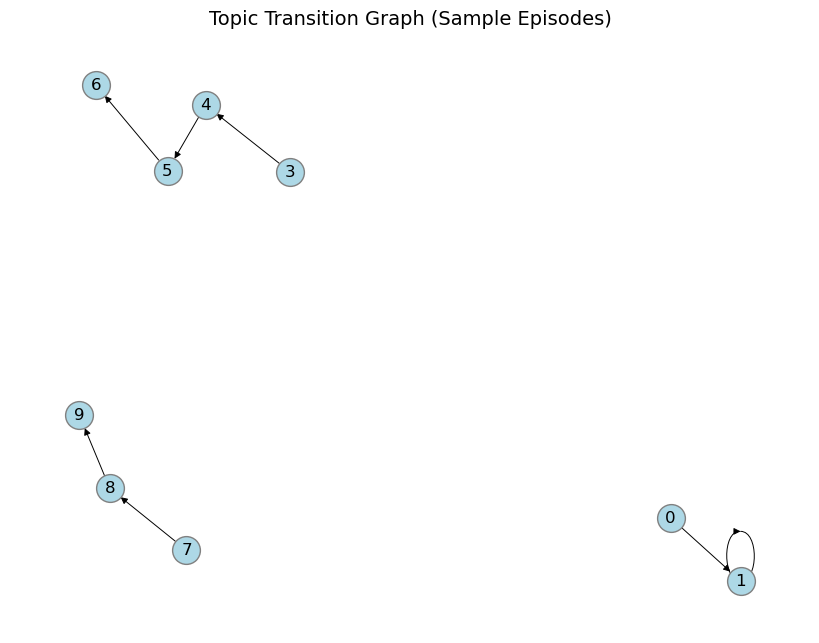

In [13]:
edges = []
for eid, group in segments_df.groupby("episode_id"):
    seq = list(group["topic"])
    for a,b in zip(seq[:-1], seq[1:]):
        edges.append((a,b))

G = nx.DiGraph()
for e in edges:
    if G.has_edge(e[0], e[1]):
        G[e[0]][e[1]]["weight"] += 1
    else:
        G.add_edge(e[0], e[1], weight=1)

# Draw the graph
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
weights = [max(0.7, min(G[u][v]["weight"]/2, 3)) for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=400, width=weights, edgecolors="gray")
plt.title("Topic Transition Graph (Sample Episodes)", fontsize=14)
plt.show()

## Pipeline

### Semantic Segmentation

### Topic Labeling

### Graph Modeling

### Visualization